# 🛰️ TLE Parsing and Orbital Analysis

This notebook extracts orbital parameters from TLE data and analyzes satellite behavior.

## Reading TLE

In [19]:
file_path = "../data/starlink.txt"

with open(file_path, "r") as f:
    lines = f.readlines()

print("Total líneas:", len(lines))
print("Ejemplo:")
print("".join(lines[:3]))

Total líneas: 60828
Ejemplo:
STARLINK-1008           

1 44714U 19074B   26098.12190329  .00063954  00000+0  18981-2 0  9998



## Convert data

In [20]:
def read_tles(lines):
    # limpiar líneas vacías
    lines = [l.strip() for l in lines if l.strip() != ""]
    
    sats = []
    
    for i in range(0, len(lines), 3):
        if i + 2 < len(lines):
            name = lines[i]
            l1 = lines[i+1]
            l2 = lines[i+2]
            
            # validar que sean líneas TLE reales
            if l1.startswith("1 ") and l2.startswith("2 "):
                sats.append({
                    "name": name,
                    "l1": l1,
                    "l2": l2,
                })
    
    return sats

sats = read_tles(lines)

print("Número de satélites:", len(sats))
print(sats[0])

Número de satélites: 10138
{'name': 'STARLINK-1008', 'l1': '1 44714U 19074B   26098.12190329  .00063954  00000+0  18981-2 0  9998', 'l2': '2 44714  53.1553  41.5837 0003189 131.3970 228.7307 15.34226723353383'}


## Parsearing orbital elements

In [21]:
def parse_tle(sat):
    l2 = sat["l2"]
    
    inclination = float(l2[8:16])
    raan = float(l2[17:25])
    eccentricity = float("0." + l2[26:33].strip())
    arg_perigee = float(l2[34:42])
    mean_anomaly = float(l2[43:51])
    mean_motion = float(l2[52:63])
    
    return {
        "name": sat["name"],
        "inclination_deg": inclination,
        "raan_deg": raan,
        "eccentricity": eccentricity,
        "arg_perigee_deg": arg_perigee,
        "mean_anomaly_deg": mean_anomaly,
        "mean_motion_rev_day": mean_motion,
    }

parsed = [parse_tle(s) for s in sats]

## Convert on a DataFrame

In [22]:
import pandas as pd

df = pd.DataFrame(parsed)
df.head()

,name,inclination_deg,raan_deg,eccentricity,arg_perigee_deg,mean_anomaly_deg,mean_motion_rev_day
0,STARLINK-1008,53.1553,41.5837,0.000319,131.3970,228.7307,15.342267
1,STARLINK-1012,53.1601,41.2277,0.000355,128.1021,232.0302,15.334823
2,STARLINK-1017,53.0528,33.4100,0.000333,129.8796,230.2495,15.270940
3,STARLINK-1019,53.0386,345.2913,0.000324,238.4455,2.8947,15.926097
4,STARLINK-1020,53.1616,64.6024,0.000296,119.8367,240.2930,15.326466


In [23]:
df.describe()

,inclination_deg,raan_deg,eccentricity,arg_perigee_deg,mean_anomaly_deg,mean_motion_rev_day
count,10138.000000,10138.000000,10138.000000,10138.000000,10138.000000,10138.000000
mean,54.592196,177.347907,0.000161,166.957260,191.583512,15.282516
std,15.096045,103.393819,0.000135,93.337803,93.955607,0.202151
min,42.975900,0.006800,0.000002,0.367000,0.274400,14.963532
25%,43.002500,92.209350,0.000110,86.373450,91.289650,15.088576
50%,53.158900,171.369100,0.000133,104.696450,250.663250,15.275888
75%,53.216900,268.883175,0.000167,268.725375,273.609700,15.302026
max,97.658300,359.916500,0.003409,359.648100,359.733200,16.331035


## Calculating orbital periods

In [24]:
df["period_minutes"] = 1440 / df["mean_motion_rev_day"]

## Some Graphics

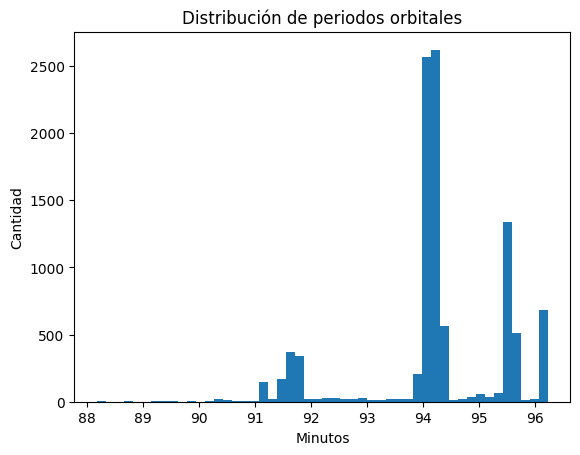

In [25]:
import matplotlib.pyplot as plt

plt.hist(df["period_minutes"], bins=50)
plt.title("Distribución de periodos orbitales")
plt.xlabel("Minutos")
plt.ylabel("Cantidad")
plt.show()

## Classify orbits

In [26]:
def classify_orbit(period):
    if period < 120:
        return "LEO"
    elif period < 1000:
        return "MEO"
    else:
        return "GEO"

df["orbit_type"] = df["period_minutes"].apply(classify_orbit)

df["orbit_type"].value_counts()

orbit_type
LEO    10138
Name: count, dtype: int64

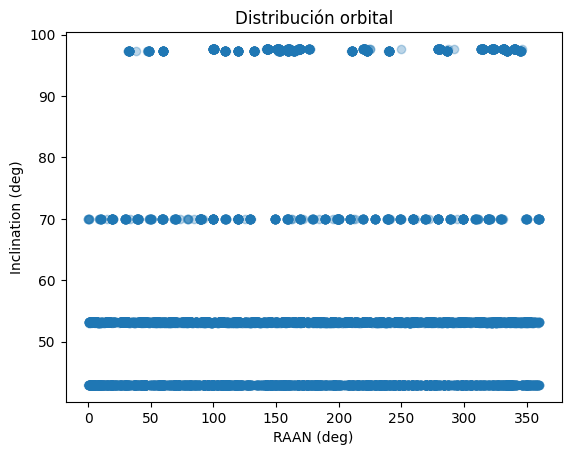

In [ ]:
plt.scatter(df["raan_deg"], df["inclination_deg"], alpha=0.3)
plt.xlabel("RAAN (deg)")
plt.ylabel("Inclination (deg)")
plt.title("Orbital_Distribution")
plt.show()